In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
BASE_PATH = "/content/drive/MyDrive/Customer-Retention-Analysis"

df = pd.read_csv(
    f"{BASE_PATH}/data/processed/clean_merged_data.csv"
)

Convert Order Purchase Timestamp to Datetime

In [ ]:
df['order_purchase_timestamp'] = pd.to_datetime(
    df['order_purchase_timestamp']
)

Calculate Total Orders Per Customer

In [ ]:
customer_orders = df.groupby(
    'customer_unique_id'
)['order_id'].nunique()

customer_orders.head()

,order_id
customer_unique_id,
0000366f3b9a7992bf8c76cfdf3221e2,1
0000b849f77a49e4a4ce2b2a4ca5be3f,1
0000f46a3911fa3c0805444483337064,1
0000f6ccb0745a6a4b88665a16c9f078,1
0004aac84e0df4da2b147fca70cf8255,1


Identify Retained Customers

In [ ]:
retained_customers = customer_orders[
    customer_orders > 1
]

retained_customers.head()

,order_id
customer_unique_id,
004288347e5e88a27ded2bb23747066c,2
00a39521eb40f7012db50455bf083460,2
00cc12a6d8b578b8ebd21ea4e2ae8b27,2
011575986092c30523ecb71ff10cb473,2
011b4adcd54683b480c4d841250a987f,2


Calculate Retention Rate
Formula:
Retention Rate= (Retained Customers/Total Customers)×100

In [ ]:
total_customers = customer_orders.count()

retained_customer_count = retained_customers.count()

retention_rate = (
    retained_customer_count / total_customers
) * 100

print("Retention Rate:", round(retention_rate, 2), "%")

Retention Rate: 3.0 %


Calculate Churn Rate
Formula:
Churn Rate=1−Retention Rate

In [ ]:
churn_rate = 100 - retention_rate

print("Churn Rate:", round(churn_rate, 2), "%")

Churn Rate: 97.0 %


Calculate Average Order Value (AOV)

In [ ]:
average_order_value = df.groupby(
    'order_id'
)['payment_value'].sum().mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 159.85


Calculate Purchase Frequency

In [ ]:
purchase_frequency = df.groupby(
    'customer_unique_id'
)['order_id'].nunique().mean()

print("Purchase Frequency:", round(purchase_frequency, 2))

Purchase Frequency: 1.03


Calculate Customer Lifespan

In [ ]:
customer_lifespan = (
    (
        df.groupby('customer_unique_id')[
            'order_purchase_timestamp'
        ].max()
        -
        df.groupby('customer_unique_id')[
            'order_purchase_timestamp'
        ].min()
    ).dt.days.mean()
) / 30

print("Customer Lifespan (Months):",
      round(customer_lifespan, 2))

Customer Lifespan (Months): 0.09


Calculate Customer Lifetime Value (LTV)
Formula:
LTV=Average Order Value×Purchase Frequency×Customer Lifespan

In [ ]:
ltv = (
    average_order_value *
    purchase_frequency *
    customer_lifespan
)

print("Customer Lifetime Value (LTV):",
      round(ltv, 2))

Customer Lifetime Value (LTV): 14.5


Visualize Retention vs Churn

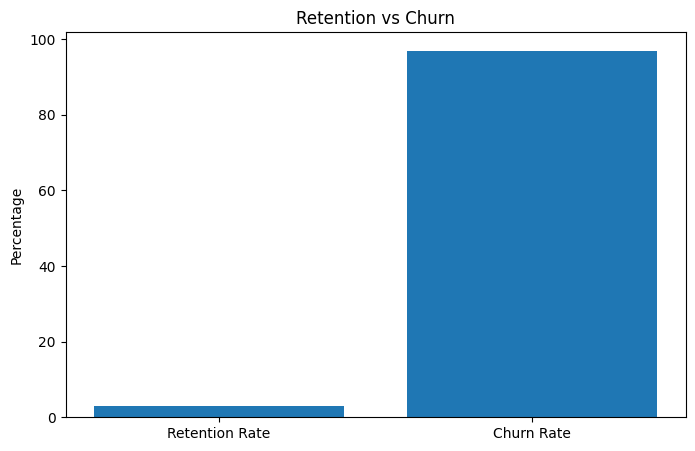

In [14]:
metrics = ['Retention Rate', 'Churn Rate']

values = [retention_rate, churn_rate]

plt.figure(figsize=(8,5))

plt.bar(metrics, values)

plt.title("Retention vs Churn")
plt.ylabel("Percentage")

plt.savefig(
    f"{BASE_PATH}/images/retention_vs_churn.png",
    bbox_inches='tight'
)

plt.show()